# seoul_air_historical_climatology_2019_2025

# 서울 러닝 추천용 Historical Air Climatology Feature Table 생성

## 목적

이 노트북은 앞 단계의 2019~2026 대기질 EDA 및 추세 분석 결과를 실제 추천 시스템에서 사용할 수 있는 **feature table**로 변환하는 최종 단계다.

핵심 결과물은:

```text
district × month × hour
```

형태의 historical air climatology이다.

각 행은 다음 의미를 가진다.

> 특정 자치구의 특정 월, 특정 시간대에서 과거에 대기질이 보통 어느 정도였는가?

---

## 기준 기간

기본 climatology는 **2019~2025 완전연도**를 사용한다.

2026년은 부분연도이므로 baseline climatology 계산에서는 제외한다.

```text
2019~2025
→ historical baseline climatology

2026
→ 최근 상태 / drift / 업데이트 판단용
```

필요하면 아래 `BASELINE_YEARS`만 수정해 새로운 baseline을 다시 만들 수 있다.

---

## 최종 구조

```text
district
month
hour

PM10 mean / median / p90
PM2.5 mean / median / p90
O3 mean / median / p90
NO2 mean / median / p90
CO mean / median / p90
SO2 mean / median / p90

서울 평균 대비 상대편차
observation_count
```

가능하면 `pm10_24h`도 동일 방식으로 함께 보존한다.

---

## 분석 파이프라인

```text
2019~2025 hourly air data
        ↓
datetime / district / pollutant 정제
        ↓
동일 시각 서울 평균 계산
        ↓
district - Seoul mean
        ↓
month / hour 파생
        ↓
district × month × hour 그룹화
        ↓
mean / median / p90 / count
        ↓
historical_air_climatology.csv
```

이 결과가 대기질 데이터 파이프라인의 최종 feature table이다.


## 1. 라이브러리

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1-1. 한글 폰트 설정

In [2]:
system_name = platform.system()

if system_name == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif system_name == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

print("한글 폰트:", plt.rcParams["font.family"])

한글 폰트: ['Malgun Gothic']


# 2. 설정

기본값은 2019~2025 완전연도다.

향후 2026년이 완전히 끝난 뒤 baseline에 추가하려면:

```python
BASELINE_YEARS = list(range(2019, 2027))
```

처럼 변경하면 된다.


In [3]:
PROJECT_DIR = Path(
    r"C:\Users\Luke\Desktop\DArtB\Toyproject"
)

RAW_DIR = PROJECT_DIR / "raw_air"
YEARLY_DIR = RAW_DIR / "yearly"

ANALYSIS_DIR = (
    PROJECT_DIR
    / "air_quality_analysis"
)

ANALYSIS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

INPUT_PATH = (
    ANALYSIS_DIR
    / "air_hourly_clean_2019_2026.csv"
)

OUTPUT_DIR = (
    ANALYSIS_DIR
    / "feature_table"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# Historical baseline
# ============================================================

BASELINE_YEARS = list(
    range(2019, 2026)
)


print("입력:", INPUT_PATH)
print("출력:", OUTPUT_DIR)
print("Baseline years:", BASELINE_YEARS)

입력: C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\air_hourly_clean_2019_2026.csv
출력: C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\feature_table
Baseline years: [2019, 2020, 2021, 2022, 2023, 2024, 2025]


# 3. 데이터 로드

앞 단계에서 만든 정제 hourly 파일을 사용한다.

```text
air_quality_analysis/
└─ air_hourly_clean_2019_2026.csv
```


In [4]:
ENCODINGS = [
    "utf-8-sig",
    "utf-8",
    "cp949",
    "euc-kr"
]


def read_csv_safe(path):
    last_error = None

    for enc in ENCODINGS:
        try:
            return pd.read_csv(
                path,
                encoding=enc,
                low_memory=False
            )
        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"CSV 읽기 실패: {path}\n{last_error}"
    )


if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"입력 파일이 없습니다.\n{INPUT_PATH}\n\n"
        "먼저 앞 단계의 EDA 노트북에서 "
        "air_hourly_clean_2019_2026.csv를 생성하세요."
    )


air = read_csv_safe(
    INPUT_PATH
)


print("shape:", air.shape)
print("columns:")
print(air.columns.tolist())

display(
    air.head()
)

shape: (1693432, 14)
columns:
['datetime', 'station', 'pm10_1h', 'pm10_24h', 'pm25', 'o3', 'no2', 'co', 'so2', 'year', 'month', 'hour', 'date', 'year_month']


,datetime,station,pm10_1h,pm10_24h,pm25,o3,no2,co,so2,year,month,hour,date,year_month
0,2019-01-01 00:00:00,강남구,35.0000,37.0000,26.0000,0.0020,0.0440,0.7000,0.0050,2019,1,0,2019-01-01,2019-01
1,2019-01-01 00:00:00,강동구,53.0000,44.0000,34.0000,0.0020,0.0730,1.1000,0.0060,2019,1,0,2019-01-01,2019-01
2,2019-01-01 00:00:00,강북구,47.0000,48.0000,26.0000,0.0160,0.0260,0.6000,0.0020,2019,1,0,2019-01-01,2019-01
3,2019-01-01 00:00:00,강서구,46.0000,52.0000,23.0000,0.0030,0.0480,0.7000,0.0070,2019,1,0,2019-01-01,2019-01
4,2019-01-01 00:00:00,관악구,36.0000,45.0000,24.0000,0.0040,0.0590,0.6000,0.0050,2019,1,0,2019-01-01,2019-01


# 4. 컬럼 확인 및 분석용 표준화

앞 단계의 표준 컬럼을 그대로 사용한다.

```text
datetime
station
pm10_1h
pm10_24h
pm25
o3
no2
co
so2
```

여기서 `station`은 추천 feature table의 `district`로 이름을 바꾼다.


In [5]:
POLLUTANTS = {
    "pm10_1h": "미세먼지 1시간",
    "pm10_24h": "미세먼지 24시간",
    "pm25": "초미세먼지",
    "o3": "오존",
    "no2": "이산화질소",
    "co": "일산화탄소",
    "so2": "아황산가스"
}


if "datetime" not in air.columns:
    raise ValueError("datetime 컬럼이 없습니다.")

if "station" not in air.columns:
    raise ValueError("station 컬럼이 없습니다.")


air["datetime"] = pd.to_datetime(
    air["datetime"],
    errors="coerce"
)

air["station"] = (
    air["station"]
    .astype(str)
    .str.strip()
)


AVAILABLE_POLLUTANTS = [
    col
    for col in POLLUTANTS
    if col in air.columns
]


for col in AVAILABLE_POLLUTANTS:
    air[col] = pd.to_numeric(
        air[col],
        errors="coerce"
    )


print("사용 가능한 pollutant:")
for col in AVAILABLE_POLLUTANTS:
    print(
        "-",
        col,
        ":",
        POLLUTANTS[col]
    )

사용 가능한 pollutant:
- pm10_1h : 미세먼지 1시간
- pm10_24h : 미세먼지 24시간
- pm25 : 초미세먼지
- o3 : 오존
- no2 : 이산화질소
- co : 일산화탄소
- so2 : 아황산가스


# 5. 2019~2025 baseline만 선택

2026년은 feature baseline에서 제외한다.


In [6]:
air["year"] = air["datetime"].dt.year
air["month"] = air["datetime"].dt.month
air["hour"] = air["datetime"].dt.hour


baseline = air[
    air["year"].isin(
        BASELINE_YEARS
    )
].copy()


baseline = baseline[
    baseline["datetime"].notna()
    &
    baseline["station"].notna()
].copy()


print(
    "Baseline 기간:",
    baseline["datetime"].min(),
    "~",
    baseline["datetime"].max()
)

print(
    "Baseline rows:",
    f"{len(baseline):,}"
)

print(
    "측정소 수:",
    baseline["station"].nunique()
)

print(
    "연도:",
    sorted(
        baseline["year"]
        .dropna()
        .unique()
    )
)

Baseline 기간: 2019-01-01 00:00:00 ~ 2025-12-31 23:00:00
Baseline rows: 1,534,197
측정소 수: 25
연도: [np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


# 6. 측정소 코드표

In [7]:
stations = sorted(
    baseline["station"]
    .dropna()
    .unique()
)


station_code_map = pd.DataFrame({
    "district_code": range(
        len(stations)
    ),
    "district": stations
})


display(
    station_code_map
)

,district_code,district
0,0,강남구
1,1,강동구
2,2,강북구
3,3,강서구
4,4,관악구
5,5,광진구
6,6,구로구
7,7,금천구
8,8,노원구
9,9,도봉구


# 7. Feature 생성 전 품질 확인

최종 feature table을 만들기 전에:

- 음수값
- 결측
- 0값
- 중복

을 확인한다.

0값은 앞 분석과 동일하게 임의 제거하지 않는다.


In [8]:
quality_rows = []


for pollutant in AVAILABLE_POLLUTANTS:

    s = baseline[pollutant]

    quality_rows.append({
        "pollutant": pollutant,
        "count": int(
            s.notna().sum()
        ),
        "missing_rate": s.isna().mean(),
        "zero_rate": s.eq(0).mean(),
        "negative_count": int(
            s.lt(0).sum()
        )
    })


quality_summary = pd.DataFrame(
    quality_rows
)


display(
    quality_summary
)


duplicate_count = baseline.duplicated(
    subset=[
        "datetime",
        "station"
    ]
).sum()


print(
    "datetime × station 중복:",
    duplicate_count
)

,pollutant,count,missing_rate,zero_rate,negative_count
0,pm10_1h,1502351,0.0208,0.0082,0
1,pm10_24h,1520831,0.0087,0.0041,0
2,pm25,1508208,0.0169,0.0059,0
3,o3,1513201,0.0137,0.0049,0
4,no2,1511838,0.0146,0.0051,0
5,co,1503438,0.0200,0.0057,0
6,so2,1506623,0.0180,0.0047,0


datetime × station 중복: 0


# 8. 같은 시각 서울 평균 계산

지역 상대 대기질은 반드시 **동일한 시각의 서울 전체 평균**과 비교한다.

```text
relative_air
=
district pollutant
-
Seoul mean pollutant at same datetime
```

예:

```text
송파구 PM2.5 = 20
같은 시각 서울 평균 PM2.5 = 27

송파구 relative PM2.5 = -7
```

음수이면 같은 시각 서울 평균보다 낮았다는 뜻이다.

이렇게 해야 황사처럼 서울 전체가 동시에 나쁜 날의 영향을 어느 정도 제거하고 지역의 상대적 성격을 볼 수 있다.


In [9]:
relative_cols = []


for pollutant in AVAILABLE_POLLUTANTS:

    city_mean_col = (
        f"{pollutant}_seoul_mean"
    )

    relative_col = (
        f"{pollutant}_relative"
    )


    baseline[
        city_mean_col
    ] = (
        baseline
        .groupby("datetime")[
            pollutant
        ]
        .transform("mean")
    )


    baseline[
        relative_col
    ] = (
        baseline[pollutant]
        -
        baseline[city_mean_col]
    )


    relative_cols.append(
        relative_col
    )


print(
    "상대편차 컬럼:"
)

print(
    relative_cols
)

상대편차 컬럼:
['pm10_1h_relative', 'pm10_24h_relative', 'pm25_relative', 'o3_relative', 'no2_relative', 'co_relative', 'so2_relative']


## 8-1. 상대편차 sanity check

동일 시각 서울 평균을 빼면 같은 시각 전체 지역의 상대편차 평균은 이론적으로 0에 가까워야 한다.


In [10]:
relative_check = {}


for col in relative_cols:

    relative_check[
        col
    ] = baseline[
        col
    ].mean()


display(
    pd.DataFrame.from_dict(
        relative_check,
        orient="index",
        columns=["overall_mean_relative"]
    )
)

,overall_mean_relative
pm10_1h_relative,-0.0000
pm10_24h_relative,-0.0000
pm25_relative,-0.0000
o3_relative,0.0000
no2_relative,0.0000
co_relative,-0.0000
so2_relative,-0.0000


# 9. `district × month × hour` climatology 생성

각 오염물질에서 다음 통계를 보존한다.

```text
mean
median
p90
observation_count
```

왜 세 가지 통계를 같이 저장하는가?

- `mean`: 장기 평균적 수준
- `median`: 극단값에 덜 민감한 전형적인 수준
- `p90`: 과거 상위 10% 고농도 상황
- `observation_count`: feature의 신뢰도 확인

추천 시스템에서 처음에는 `median`을 baseline으로 사용하고,  
고농도 위험을 반영하려면 `p90`을 추가하는 방식이 해석하기 쉽다.


In [11]:
def p90(series):
    return series.quantile(
        0.90
    )


group_keys = [
    "station",
    "month",
    "hour"
]


feature_parts = []


# ============================================================
# Absolute climatology
# ============================================================

for pollutant in AVAILABLE_POLLUTANTS:

    temp = (
        baseline
        .groupby(
            group_keys
        )[pollutant]
        .agg(
            mean="mean",
            median="median",
            p90=p90,
            observation_count="count"
        )
        .reset_index()
    )


    temp = temp.rename(
        columns={
            "mean":
                f"{pollutant}_mean",

            "median":
                f"{pollutant}_median",

            "p90":
                f"{pollutant}_p90",

            "observation_count":
                f"{pollutant}_observation_count"
        }
    )


    feature_parts.append(
        temp
    )


# ============================================================
# Merge pollutant tables
# ============================================================

climatology = feature_parts[0]


for temp in feature_parts[1:]:

    climatology = climatology.merge(
        temp,
        on=group_keys,
        how="outer"
    )


print(
    "Absolute climatology shape:",
    climatology.shape
)


display(
    climatology.head()
)

Absolute climatology shape: (7200, 31)


,station,month,hour,pm10_1h_mean,pm10_1h_median,pm10_1h_p90,pm10_1h_observation_count,pm10_24h_mean,pm10_24h_median,pm10_24h_p90,pm10_24h_observation_count,pm25_mean,pm25_median,pm25_p90,pm25_observation_count,o3_mean,o3_median,o3_p90,o3_observation_count,no2_mean,no2_median,no2_p90,no2_observation_count,co_mean,co_median,co_p90,co_observation_count,so2_mean,so2_median,so2_p90,so2_observation_count
0,강남구,1,0,40.6157,34.0000,69.5000,216,41.1198,37.0000,67.4000,217,26.5991,21.0000,47.2000,217,0.0142,0.0130,0.0290,217,0.0330,0.0330,0.0540,217,0.5972,0.5200,0.9000,217,0.0035,0.0030,0.0054,217
1,강남구,1,1,41.8796,34.0000,68.5000,216,40.7834,36.0000,65.8000,217,27.9493,22.0000,48.0000,217,0.0142,0.0120,0.0291,217,0.0319,0.0310,0.0530,217,0.5955,0.5500,0.9000,217,0.0035,0.0030,0.0060,217
2,강남구,1,2,39.9724,32.0000,70.4000,217,40.4885,36.0000,67.0000,217,27.0184,20.0000,48.4000,217,0.0146,0.0130,0.0300,216,0.0304,0.0290,0.0520,217,0.5945,0.5400,0.9000,217,0.0035,0.0030,0.0060,217
3,강남구,1,3,41.4444,33.5000,72.0000,216,40.2166,35.0000,67.0000,217,27.9493,21.0000,50.0000,217,0.0148,0.0132,0.0300,217,0.0290,0.0280,0.0500,217,0.5815,0.5000,0.9000,217,0.0034,0.0030,0.0050,217
4,강남구,1,4,39.4147,32.0000,68.4000,217,39.9770,34.0000,67.4000,217,27.0276,21.0000,49.0000,217,0.0147,0.0140,0.0294,217,0.0279,0.0270,0.0463,217,0.5676,0.5000,0.8620,217,0.0034,0.0030,0.0060,217


# 10. 서울 평균 대비 상대편차 climatology

절대농도와 별도로 같은 시각 서울 평균 대비 상대편차를 집계한다.

추천에서는 이 feature가 지역별 보정값 역할을 할 수 있다.


In [12]:
relative_parts = []


for pollutant in AVAILABLE_POLLUTANTS:

    relative_col = (
        f"{pollutant}_relative"
    )


    temp = (
        baseline
        .groupby(
            group_keys
        )[relative_col]
        .agg(
            relative_mean="mean",
            relative_median="median",
            relative_p90=p90,
            relative_observation_count="count"
        )
        .reset_index()
    )


    temp = temp.rename(
        columns={
            "relative_mean":
                f"{pollutant}_relative_mean",

            "relative_median":
                f"{pollutant}_relative_median",

            "relative_p90":
                f"{pollutant}_relative_p90",

            "relative_observation_count":
                f"{pollutant}_relative_observation_count"
        }
    )


    relative_parts.append(
        temp
    )


relative_climatology = (
    relative_parts[0]
)


for temp in relative_parts[1:]:

    relative_climatology = (
        relative_climatology.merge(
            temp,
            on=group_keys,
            how="outer"
        )
    )


print(
    "Relative climatology shape:",
    relative_climatology.shape
)


display(
    relative_climatology.head()
)

Relative climatology shape: (7200, 31)


,station,month,hour,pm10_1h_relative_mean,pm10_1h_relative_median,pm10_1h_relative_p90,pm10_1h_relative_observation_count,pm10_24h_relative_mean,pm10_24h_relative_median,pm10_24h_relative_p90,pm10_24h_relative_observation_count,pm25_relative_mean,pm25_relative_median,pm25_relative_p90,pm25_relative_observation_count,o3_relative_mean,o3_relative_median,o3_relative_p90,o3_relative_observation_count,no2_relative_mean,no2_relative_median,no2_relative_p90,no2_relative_observation_count,co_relative_mean,co_relative_median,co_relative_p90,co_relative_observation_count,so2_relative_mean,so2_relative_median,so2_relative_p90,so2_relative_observation_count
0,강남구,1,0,-2.2239,-1.9167,2.8211,216,-1.6697,-1.4000,1.6000,217,-0.0678,-0.0800,3.1920,217,0.0003,-0.0001,0.0042,217,-0.0008,-0.0010,0.0049,217,-0.0538,-0.0471,0.0368,217,0.0001,0.0000,0.0009,217
1,강남구,1,1,-1.7884,-1.7350,3.7648,216,-1.6369,-1.2400,1.5360,217,0.4827,-0.0800,4.1200,217,0.0002,-0.0002,0.0041,217,-0.0007,-0.0006,0.0057,217,-0.0552,-0.0440,0.0336,217,0.0001,0.0001,0.0009,217
2,강남구,1,2,-2.2797,-2.0800,2.3827,217,-1.6099,-1.2400,1.7440,217,0.0674,-0.3200,3.5287,217,0.0003,-0.0001,0.0044,216,-0.0008,-0.0006,0.0045,217,-0.0540,-0.0452,0.0285,217,0.0002,0.0001,0.0012,217
3,강남구,1,3,-1.7607,-1.7133,3.8400,216,-1.6795,-1.5200,1.7440,217,0.3008,-0.2000,4.0480,217,0.0003,-0.0002,0.0046,217,-0.0009,-0.0006,0.0052,217,-0.0582,-0.0516,0.0262,217,0.0001,0.0000,0.0010,217
4,강남구,1,4,-2.5685,-2.2000,1.4102,217,-1.7257,-1.4400,1.2220,217,0.1063,-0.1600,2.5760,217,0.0004,0.0000,0.0046,217,-0.0013,-0.0014,0.0046,217,-0.0666,-0.0582,0.0102,217,0.0001,-0.0000,0.0009,217


# 11. 최종 feature table 결합

절대 climatology + 상대 climatology를 하나로 합친다.


In [13]:
air_feature = climatology.merge(
    relative_climatology,
    on=group_keys,
    how="outer"
)


air_feature = air_feature.rename(
    columns={
        "station":
            "district"
    }
)


# district code 추가
air_feature = air_feature.merge(
    station_code_map,
    on="district",
    how="left"
)


# 보기 좋은 순서
front_cols = [
    "district_code",
    "district",
    "month",
    "hour"
]


remaining_cols = [
    c
    for c in air_feature.columns
    if c not in front_cols
]


air_feature = air_feature[
    front_cols
    +
    remaining_cols
]


air_feature = (
    air_feature
    .sort_values(
        [
            "district_code",
            "month",
            "hour"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "FINAL feature shape:",
    air_feature.shape
)


display(
    air_feature.head(20)
)

FINAL feature shape: (7200, 60)


,district_code,district,month,hour,pm10_1h_mean,pm10_1h_median,pm10_1h_p90,pm10_1h_observation_count,pm10_24h_mean,pm10_24h_median,pm10_24h_p90,pm10_24h_observation_count,pm25_mean,pm25_median,pm25_p90,pm25_observation_count,o3_mean,o3_median,o3_p90,o3_observation_count,no2_mean,no2_median,no2_p90,no2_observation_count,co_mean,co_median,co_p90,co_observation_count,so2_mean,so2_median,so2_p90,so2_observation_count,pm10_1h_relative_mean,pm10_1h_relative_median,pm10_1h_relative_p90,pm10_1h_relative_observation_count,pm10_24h_relative_mean,pm10_24h_relative_median,pm10_24h_relative_p90,pm10_24h_relative_observation_count,pm25_relative_mean,pm25_relative_median,pm25_relative_p90,pm25_relative_observation_count,o3_relative_mean,o3_relative_median,o3_relative_p90,o3_relative_observation_count,no2_relative_mean,no2_relative_median,no2_relative_p90,no2_relative_observation_count,co_relative_mean,co_relative_median,co_relative_p90,co_relative_observation_count,so2_relative_mean,so2_relative_median,so2_relative_p90,so2_relative_observation_count
0,0,강남구,1,0,40.6157,34.0000,69.5000,216,41.1198,37.0000,67.4000,217,26.5991,21.0000,47.2000,217,0.0142,0.0130,0.0290,217,0.0330,0.0330,0.0540,217,0.5972,0.5200,0.9000,217,0.0035,0.0030,0.0054,217,-2.2239,-1.9167,2.8211,216,-1.6697,-1.4000,1.6000,217,-0.0678,-0.0800,3.1920,217,0.0003,-0.0001,0.0042,217,-0.0008,-0.0010,0.0049,217,-0.0538,-0.0471,0.0368,217,0.0001,0.0000,0.0009,217
1,0,강남구,1,1,41.8796,34.0000,68.5000,216,40.7834,36.0000,65.8000,217,27.9493,22.0000,48.0000,217,0.0142,0.0120,0.0291,217,0.0319,0.0310,0.0530,217,0.5955,0.5500,0.9000,217,0.0035,0.0030,0.0060,217,-1.7884,-1.7350,3.7648,216,-1.6369,-1.2400,1.5360,217,0.4827,-0.0800,4.1200,217,0.0002,-0.0002,0.0041,217,-0.0007,-0.0006,0.0057,217,-0.0552,-0.0440,0.0336,217,0.0001,0.0001,0.0009,217
2,0,강남구,1,2,39.9724,32.0000,70.4000,217,40.4885,36.0000,67.0000,217,27.0184,20.0000,48.4000,217,0.0146,0.0130,0.0300,216,0.0304,0.0290,0.0520,217,0.5945,0.5400,0.9000,217,0.0035,0.0030,0.0060,217,-2.2797,-2.0800,2.3827,217,-1.6099,-1.2400,1.7440,217,0.0674,-0.3200,3.5287,217,0.0003,-0.0001,0.0044,216,-0.0008,-0.0006,0.0045,217,-0.0540,-0.0452,0.0285,217,0.0002,0.0001,0.0012,217
3,0,강남구,1,3,41.4444,33.5000,72.0000,216,40.2166,35.0000,67.0000,217,27.9493,21.0000,50.0000,217,0.0148,0.0132,0.0300,217,0.0290,0.0280,0.0500,217,0.5815,0.5000,0.9000,217,0.0034,0.0030,0.0050,217,-1.7607,-1.7133,3.8400,216,-1.6795,-1.5200,1.7440,217,0.3008,-0.2000,4.0480,217,0.0003,-0.0002,0.0046,217,-0.0009,-0.0006,0.0052,217,-0.0582,-0.0516,0.0262,217,0.0001,0.0000,0.0010,217
4,0,강남구,1,4,39.4147,32.0000,68.4000,217,39.9770,34.0000,67.4000,217,27.0276,21.0000,49.0000,217,0.0147,0.0140,0.0294,217,0.0279,0.0270,0.0463,217,0.5676,0.5000,0.8620,217,0.0034,0.0030,0.0060,217,-2.5685,-2.2000,1.4102,217,-1.7257,-1.4400,1.2220,217,0.1063,-0.1600,2.5760,217,0.0004,0.0000,0.0046,217,-0.0013,-0.0014,0.0046,217,-0.0666,-0.0582,0.0102,217,0.0001,-0.0000,0.0009,217
5,0,강남구,1,5,40.5349,34.0000,70.0000,215,39.6221,34.0000,66.4000,217,27.7880,22.0000,51.4000,217,0.0141,0.0125,0.0289,217,0.0276,0.0280,0.0450,217,0.5707,0.5000,0.8260,217,0.0034,0.0030,0.0050,217,-2.0794,-1.6800,2.5920,215,-1.8774,-1.7917,1.0000,217,0.4485,0.0800,4.0720,217,0.0007,0.0001,0.0047,217,-0.0019,-0.0018,0.0031,217,-0.0651,-0.0530,0.0262,217,0.0001,0.0000,0.0010,217
6,0,강남구,1,6,38.8802,33.0000,68.4000,217,39.3180,34.0000,65.0000,217,27.0139,22.0000,51.0000,216,0.0126,0.0100,0.0271,217,0.0290,0.0300,0.0450,217,0.5731,0.5900,0.8040,217,0.0034,0.0030,0.0050,217,-2.6725,-2.5200,2.1920,217,-2.0593,-1.6800,0.9687,217,0.2486,-0.1600,4.2000,216,0.0010,0.0005,0.0058,217,-0.0025,-0.0023,0.0025,217,-0.0772,-0.0657,0.0136,217,0.0001,0.0000,0.0009,217
7,0,강남구,1,7,40.2698,34.0000,67.6000,215,39.0968,34.0000,64.8000,217,27.6498,22.0000,53.0000,217,0.0099,0.0050,0.0234,217,0.0324,0.0350,0.0470,217,0.5916,0.6000,0.8880,217,0.0034,0.0030,0.0050,217,-2.6118,-2.0000,1.9200,215,-2.1749,-1.9600,0.8110,217,0.0823,0.0833,4.6000,217,0.0004,-0

# 12. Feature table 완전성 검증

25개 구 × 12개월 × 24시간이면 이론상:

```text
25 × 12 × 24 = 7,200 rows
```

가 된다.


In [14]:
expected_rows = (
    len(stations)
    * 12
    * 24
)


actual_rows = len(
    air_feature
)


print(
    "Expected rows:",
    expected_rows
)

print(
    "Actual rows:",
    actual_rows
)


if actual_rows == expected_rows:

    print(
        "✓ 모든 district × month × hour 조합이 존재합니다."
    )

else:

    print(
        "⚠ 일부 district × month × hour 조합이 없습니다."
    )


# ============================================================
# 조합 누락 확인
# ============================================================

full_index = pd.MultiIndex.from_product(
    [
        stations,
        range(1, 13),
        range(24)
    ],
    names=[
        "district",
        "month",
        "hour"
    ]
)


actual_index = pd.MultiIndex.from_frame(
    air_feature[
        [
            "district",
            "month",
            "hour"
        ]
    ]
)


missing_combinations = (
    full_index
    .difference(
        actual_index
    )
)


print(
    "누락 조합 수:",
    len(
        missing_combinations
    )
)


if len(
    missing_combinations
):

    display(
        pd.DataFrame(
            missing_combinations.tolist(),
            columns=[
                "district",
                "month",
                "hour"
            ]
        ).head(100)
    )

Expected rows: 7200
Actual rows: 7200
✓ 모든 district × month × hour 조합이 존재합니다.
누락 조합 수: 0


# 13. Observation count 확인

같은 `month × hour`은 7개 연도의 해당 월 날짜 수만큼 관측 기회가 있다.

관측 수가 비정상적으로 작은 feature는 향후 추천에서 신뢰도를 낮게 볼 수 있다.


In [15]:
count_cols = [
    c
    for c in air_feature.columns
    if c.endswith(
        "_observation_count"
    )
    and
    "_relative_" not in c
]


count_summary_rows = []


for col in count_cols:

    count_summary_rows.append({
        "feature": col,
        "min": air_feature[col].min(),
        "median": air_feature[col].median(),
        "mean": air_feature[col].mean(),
        "max": air_feature[col].max()
    })


count_summary = pd.DataFrame(
    count_summary_rows
)


display(
    count_summary
)

,feature,min,median,mean,max
0,pm10_1h_observation_count,170,210.0000,208.6599,217
1,pm10_24h_observation_count,175,214.0000,211.2265,217
2,pm25_observation_count,171,210.0000,209.4733,217
3,o3_observation_count,170,210.0000,210.1668,217
4,no2_observation_count,167,210.0000,209.9775,217
5,co_observation_count,170,210.0000,208.8108,217
6,so2_observation_count,154,210.0000,209.2532,217


# 14. Feature table 사용 예시

예를 들어:

```text
송파구
7월
06시
```

의 historical air context를 조회할 수 있다.


In [16]:
EXAMPLE_DISTRICT = (
    "송파구"
    if "송파구" in stations
    else stations[0]
)

EXAMPLE_MONTH = 7
EXAMPLE_HOUR = 6


example = air_feature[
    (
        air_feature["district"]
        == EXAMPLE_DISTRICT
    )
    &
    (
        air_feature["month"]
        == EXAMPLE_MONTH
    )
    &
    (
        air_feature["hour"]
        == EXAMPLE_HOUR
    )
]


display(
    example.T
)

,5046
district_code,17
district,송파구
month,7
hour,6
pm10_1h_mean,22.3568
pm10_1h_median,21.0000
pm10_1h_p90,38.0000
pm10_1h_observation_count,213
pm10_24h_mean,23.3551
pm10_24h_median,22.0000


# 15. Climatology sanity visualization

feature table이 의도한 패턴을 보존하고 있는지 대표 오염물질을 간단히 확인한다.


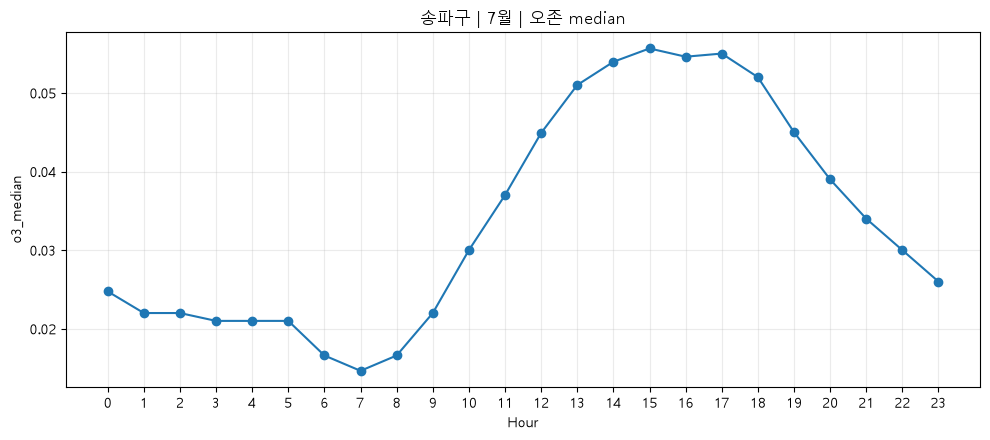

In [17]:
def plot_climatology_hourly(
    district,
    month,
    pollutant,
    stat="median"
):

    col = (
        f"{pollutant}_{stat}"
    )

    if col not in air_feature.columns:
        raise ValueError(
            f"없는 feature: {col}"
        )

    temp = air_feature[
        (
            air_feature["district"]
            == district
        )
        &
        (
            air_feature["month"]
            == month
        )
    ].sort_values(
        "hour"
    )


    plt.figure(
        figsize=(10, 4.5)
    )

    plt.plot(
        temp["hour"],
        temp[col],
        marker="o"
    )

    plt.title(
        f"{district} | "
        f"{month}월 | "
        f"{POLLUTANTS.get(pollutant, pollutant)} "
        f"{stat}"
    )

    plt.xlabel("Hour")
    plt.ylabel(col)
    plt.xticks(
        range(24)
    )
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


if "o3" in AVAILABLE_POLLUTANTS:

    plot_climatology_hourly(
        EXAMPLE_DISTRICT,
        7,
        "o3",
        stat="median"
    )

# 16. 모델 입력용 compact table

현재 `air_feature`는 분석과 향후 실험을 위해 많은 통계를 모두 보존한다.

실제 MVP 추천 모델에서는 처음부터 모든 컬럼을 사용할 필요는 없다.

초기 추천 feature는 다음처럼 단순하게 시작할 수 있다.

```text
district
month
hour

pm10_1h_median
pm25_median
o3_median
no2_median

pm10_1h_p90
pm25_p90
o3_p90

pm10_1h_relative_median
pm25_relative_median
o3_relative_median
no2_relative_median
```

필요에 따라 CO, SO₂, PM10 24시간을 추가한다.


In [18]:
compact_candidates = [
    "district_code",
    "district",
    "month",
    "hour",

    "pm10_1h_median",
    "pm25_median",
    "o3_median",
    "no2_median",

    "pm10_1h_p90",
    "pm25_p90",
    "o3_p90",

    "pm10_1h_relative_median",
    "pm25_relative_median",
    "o3_relative_median",
    "no2_relative_median"
]


compact_cols = [
    c
    for c in compact_candidates
    if c in air_feature.columns
]


air_feature_compact = air_feature[
    compact_cols
].copy()


print(
    "Compact shape:",
    air_feature_compact.shape
)


display(
    air_feature_compact.head(20)
)

Compact shape: (7200, 15)


,district_code,district,month,hour,pm10_1h_median,pm25_median,o3_median,no2_median,pm10_1h_p90,pm25_p90,o3_p90,pm10_1h_relative_median,pm25_relative_median,o3_relative_median,no2_relative_median
0,0,강남구,1,0,34.0000,21.0000,0.0130,0.0330,69.5000,47.2000,0.0290,-1.9167,-0.0800,-0.0001,-0.0010
1,0,강남구,1,1,34.0000,22.0000,0.0120,0.0310,68.5000,48.0000,0.0291,-1.7350,-0.0800,-0.0002,-0.0006
2,0,강남구,1,2,32.0000,20.0000,0.0130,0.0290,70.4000,48.4000,0.0300,-2.0800,-0.3200,-0.0001,-0.0006
3,0,강남구,1,3,33.5000,21.0000,0.0132,0.0280,72.0000,50.0000,0.0300,-1.7133,-0.2000,-0.0002,-0.0006
4,0,강남구,1,4,32.0000,21.0000,0.0140,0.0270,68.4000,49.0000,0.0294,-2.2000,-0.1600,0.0000,-0.0014
5,0,강남구,1,5,34.0000,22.0000,0.0125,0.0280,70.0000,51.4000,0.0289,-1.6800,0.0800,0.0001,-0.0018
6,0,강남구,1,6,33.0000,22.0000,0.0100,0.0300,68.4000,51.0000,0.0271,-2.5200,-0.1600,0.0005,-0.0023
7,0,강남구,1,7,34.0000,22.0000,0.0050,0.0350,67.6000,53.0000,0.0234,-2.0000,0.0833,-0.0001,-0.0022
8,0,강남구,1,8,33.5000,22.0000,0.0030,0.0380,65.0000,49.4000,0.0210,-2.9392,-0.4000,-0.0004,-0.0014
9,0,강남구,1,9,36.0000,23.0000,0.0040,0.0383,67.2000,49.4000,0.0198,-2.7600,-0.4800,-0.0005,-0.0014


# 17. 최종 저장

두 가지 파일을 만든다.

### Full

분석 및 향후 실험용.  
모든 pollutant의 mean / median / p90 / relative / count를 보존한다.

```text
historical_air_climatology_full_2019_2025.csv
```

### Compact

초기 러닝 추천 MVP용.

```text
historical_air_climatology_compact_2019_2025.csv
```


In [19]:
FULL_PATH = (
    OUTPUT_DIR
    / "historical_air_climatology_full_2019_2025.csv"
)

COMPACT_PATH = (
    OUTPUT_DIR
    / "historical_air_climatology_compact_2019_2025.csv"
)

STATION_MAP_PATH = (
    OUTPUT_DIR
    / "station_code_map.csv"
)


air_feature.to_csv(
    FULL_PATH,
    index=False,
    encoding="utf-8-sig"
)


air_feature_compact.to_csv(
    COMPACT_PATH,
    index=False,
    encoding="utf-8-sig"
)


station_code_map.to_csv(
    STATION_MAP_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "✓ FULL:"
)
print(
    FULL_PATH
)

print(
    "\n✓ COMPACT:"
)
print(
    COMPACT_PATH
)

print(
    "\n✓ STATION MAP:"
)
print(
    STATION_MAP_PATH
)

✓ FULL:
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\feature_table\historical_air_climatology_full_2019_2025.csv

✓ COMPACT:
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\feature_table\historical_air_climatology_compact_2019_2025.csv

✓ STATION MAP:
C:\Users\Luke\Desktop\DArtB\Toyproject\air_quality_analysis\feature_table\station_code_map.csv


# 18. 최종 데이터 구조 설명 

## Key

| 컬럼 | 의미 |
|---|---|
| `district_code` | 측정소/자치구 코드 |
| `district` | 자치구 |
| `month` | 월 (1~12) |
| `hour` | 시간 (0~23) |

---

## Absolute feature

예:

```text
pm25_mean
pm25_median
pm25_p90
pm25_observation_count
```

의 의미는:

> 해당 자치구 × 월 × 시간 조합에서 2019~2025년 PM2.5의 historical distribution

이다.

---

## Relative feature

예:

```text
pm25_relative_median
```

은 먼저 매 시간:

```text
해당 구 PM2.5
-
같은 시간 서울 25개 구 평균 PM2.5
```

를 계산한 뒤, 동일한 `district × month × hour`에서 median을 계산한 값이다.

### 해석

```text
relative < 0
→ 같은 시각 서울 평균보다 과거에 상대적으로 낮은 편

relative > 0
→ 같은 시각 서울 평균보다 과거에 상대적으로 높은 편
```

---

## mean vs median vs p90

| 통계 | 추천에서의 의미 |
|---|---|
| `mean` | 장기 평균 |
| `median` | 평소/전형적인 상태 |
| `p90` | 과거 고농도 상황 |
| `observation_count` | 통계 신뢰도 확인 |

초기 추천 시스템에서는 **median을 기본값**으로 사용하는 것이 해석하기 쉽다.

`p90`은 위험 회피나 보수적인 추천에 활용할 수 있다.


# 19. 대기질 파이프라인 최종 결론

이 단계까지 완료하면 대기질 데이터의 offline historical pipeline은 끝난다.

```text
서울 대기질 raw data
        ↓
2019~2026 정제
        ↓
EDA / 추세 분석
        ↓
2019~2025 historical baseline
        ↓
district × month × hour climatology
        ↓
historical_air_context_feature
```

다음 단계에서는 더 이상 대기질 자체를 분석하는 것이 아니라 **추천 데이터셋을 조립**한다.

```text
[Route Feature Table]
route_id
geometry
district
distance
elevation
green_ratio
shade_ratio
...

          +

[Historical Air Feature Table]
district
month
hour
PM / O3 / NO2 climatology
relative air features

          +

[Weather Feature Table]
month
hour
temperature
humidity
rain
wind
solar radiation
visibility

          ↓

[Recommendation Dataset]
route_id × month × hour
```

따라서 이 노트북의 출력인:

```text
historical_air_climatology_full_2019_2025.csv
```

가 **대기질 파트의 최종 산출물**이다.

향후 실시간 추천으로 확장할 경우:

```text
Historical climatology
        +
Current air quality
        +
Current weather
        ↓
Real-time running recommendation
```

구조로 확장한다.
